# AR(p) Parameter Estimation

The $\text{AR}(p)$ process is defined by,

$
\begin{align}
X_t = \sum_{i=1}^p \varphi_i X_{t-i} + \varepsilon_{t}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

The Yule-Walker equations are relate the AR(p) parameters $\varphi_i$ to the autocorrelation function. If zero mean is</br>
assumed it follows that,

$
\begin{align}
\rho_n = \frac{\text{E}[X_t X_{t-n}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

The autocorrelation functions can be shown to have the following properties,

$
\begin{align}
&\rho_0 = 1 \\
&\rho_n \leq 1 \\
&\rho_n = \rho_{-n}
\end{align}
\tag{4}
$

Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{n-1} \\
\rho_{n}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{n-1} \\
\varphi_{n}
\end{bmatrix}
\end{align}
\tag{6}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-2} & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-3} & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-4} & \rho_{n-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{n-2} & \rho_{n-3} & \rho_{n-4} & \cdots & 1 & \rho_1 \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{7}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

## Examples

The Yule-Walker equations for $\text{AR}(1)$ is given by,

$
\begin{align}
\varphi_1 = \rho_1
\end{align}
\tag{9}
$

This is the OLS solution.

For $\text{AR}(2)$,

$
\begin{align}
\varphi_1 &= \frac{\rho_1 - \rho_1 \rho_2}{1 - \rho_1^2} \\
\varphi_2 &= \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2}
\end{align}
\tag{10}
$

## Stationaity

Stationarity of an $\text{AR}(p)$ leads to convergence of the moments as $t \to \infty$. Recall the shift operator, $L$, defined by,

$
\begin{align}
&L X_t = X_{t-1} \\
&L^2 X_t = X_{t-2} \\
&L^3 X_t = X_{t-3} \\
&\vdots
\end{align}
\tag{11}
$

An $\text{AR}(p)$ process can be written as,

$
\begin{align}
\varepsilon_t = (1 - \varphi L - \varphi^2 L^2 - \varphi^3 L^3 - \cdots - \varphi^p L^p) X_t
\end{align}
\tag{12}
$

The characteristic equation is obtained by replacing $L$ with the variable $z$ and setting the result to zero,

$
\begin{align}
1 - \varphi z - \varphi^2 z^2 - \varphi^3 z^3 - \cdots - \varphi^p z^p = 0
\end{align}
\tag{13}
$

Stationarity requires that $\lvert z \rvert > 1$. To see this consider $\text{AR}(1)$. The characteristic equation is,

$
\begin{align}
1 - \varphi z = 0
\end{align}
\tag{14}
$

The solution is $z = \frac{1}{\varphi}$. It follows that stationarity requires,

$
\begin{align}
\lvert \varphi \rvert < 1
\end{align}
\tag{15}
$

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6))
    return t, scan

## Simulations

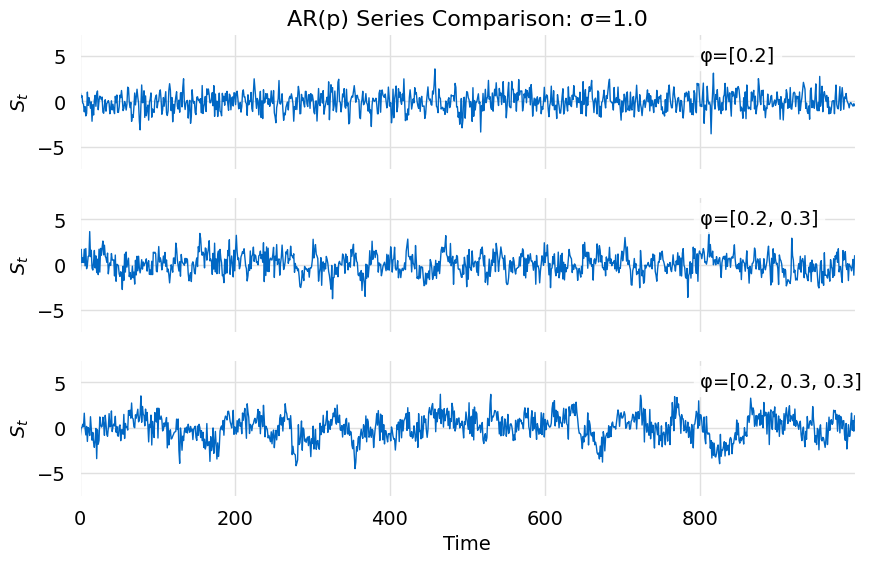

In [3]:
σ = 1.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-7.5, 7.5], *params)

## Estimation of $\text{AR}(p)$ Parameters ($\sigma = 1$)

$\text{AR}(p)$ parameters are estimated using two methods. The Yule-Walker ACF and `statsmodels.tsa.arima_model.ARMA`

### AR(1) Example $\varphi = 0.2$

In [4]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.16805615]))

In [5]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1423.805
Date:                Sun, 23 Jul 2023   AIC                           2853.609
Time:                        11:22:00   BIC                           2868.332
Sample:                             0   HQIC                          2859.205
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0052      0.038     -0.137      0.891      -0.080       0.070
ar.L1          0.1679      0.031      5.390      0.000       0.107       0.229
sigma2         1.0097      0.045     22.239      0.000       0.921       1.099
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.50
Prob(Q):                              1.00   Prob(JB):                         0.78
Heteroskedasticity (H):               1.03   Skew:                            -0.05
Prob(H) (two-sided):                  0.80   Kurtosis:                         2.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR',
 'order': 1,
 'const': {'Estimate': -0.0052361522217098,
  'Error': 0.03826256094187739,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 1.0097402313122754,
  'Error': 0.04540321156008391,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.16794996195173886,
   'Error': 0.03115938416732305,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'}]}

### AR(2) Example $\varphi = [0.2, 0.3]$

In [7]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.2069283 , 0.35388825]))

In [8]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1419.698
Date:                Sun, 23 Jul 2023   AIC                           2847.397
Time:                        11:22:00   BIC                           2867.028
Sample:                             0   HQIC                          2854.858
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0613      0.072      0.852      0.394      -0.080       0.202
ar.L1          0.2062      0.029      7.027      0.000       0.149       0.264
ar.L2          0.3543      0.031     11.468      0.000       0.294       0.415
sigma2         1.0011      0.045     22.441      0.000       0.914       1.089
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                 0.56
Prob(Q):                              0.71   Prob(JB):                         0.76
Heteroskedasticity (H):               0.95   Skew:                             0.06
Prob(H) (two-sided):                  0.63   Kurtosis:                         3.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR',
 'order': 2,
 'const': {'Estimate': 0.06131783715921126,
  'Error': 0.07196786444126926,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 1.0011427939075301,
  'Error': 0.04461237632757959,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.20622946388318497,
   'Error': 0.02934705841916214,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'},
  {'Estimate': 0.3542743395525066,
   'Error': 0.0308934651346098,
   'Estimate Label': '$\\hat{\\phi_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{1}}}$'}]}

### AR(3) Example $\varphi = [0.2, 0.3, 0.3]$

In [10]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.17819819, 0.30832933, 0.30874515]))

In [11]:
result, result_model = arima.compute_ar_estimate(ar[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1449.291
Date:                Sun, 23 Jul 2023   AIC                           2908.583
Time:                        11:22:00   BIC                           2933.122
Sample:                             0   HQIC                          2917.909
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0194      0.158      0.122      0.903      -0.291       0.329
ar.L1          0.1780      0.029      6.194      0.000       0.122       0.234
ar.L2          0.3082      0.030     10.233      0.000       0.249       0.367
ar.L3          0.3086      0.030     10.161      0.000       0.249       0.368
sigma2         1.0616      0.049     21.807      0.000       0.966       1.157
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                 0.26
Prob(Q):                              0.71   Prob(JB):                         0.88
Heteroskedasticity (H):               0.97   Skew:                            -0.03
Prob(H) (two-sided):                  0.75   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR',
 'order': 3,
 'const': {'Estimate': 0.019377289191322738,
  'Error': 0.15820310147815475,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 1.061574267335463,
  'Error': 0.048679621459169986,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.17795652949322438,
   'Error': 0.028729192719858375,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'},
  {'Estimate': 0.3081632474681079,
   'Error': 0.030115678016346736,
   'Estimate Label': '$\\hat{\\phi_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{1}}}$'},
  {'Estimate': 0.30855953249832824,
   'Error': 0.030365628633093465,
   'Estimate Label': '$\\hat{\\phi_{2}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{2}}}$'}]}

## Simulations $\sigma = 5.0$

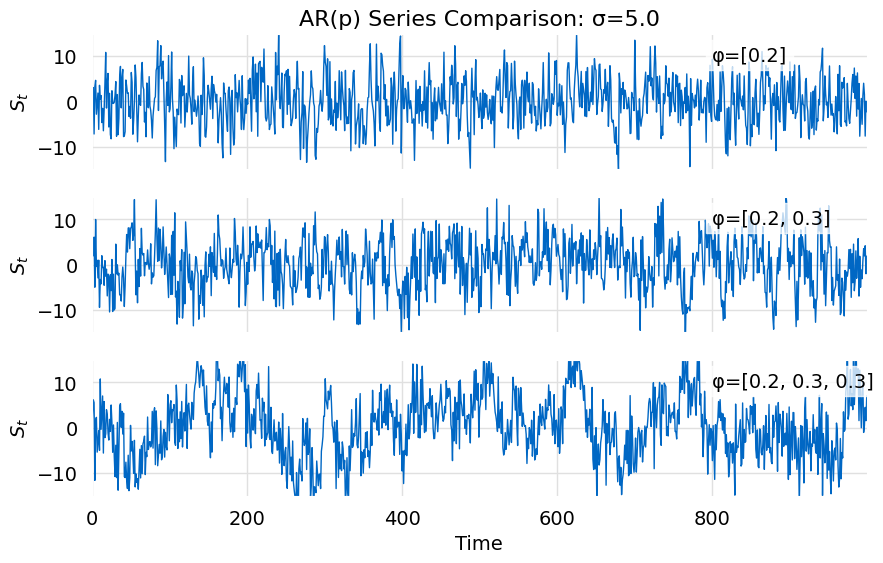

In [13]:
σ = 5.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-15.0, 15.0], *params)

### AR(1) Example ($\varphi = 0.2$)

In [14]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.29148996]))

In [15]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3018.162
Date:                Sun, 23 Jul 2023   AIC                           6042.324
Time:                        11:22:00   BIC                           6057.047
Sample:                             0   HQIC                          6047.920
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1129      0.221      0.511      0.609      -0.320       0.546
ar.L1          0.2915      0.028     10.283      0.000       0.236       0.347
sigma2        24.4915      1.171     20.908      0.000      22.196      26.787
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.64
Prob(Q):                              0.96   Prob(JB):                         0.27
Heteroskedasticity (H):               0.88   Skew:                             0.01
Prob(H) (two-sided):                  0.26   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR',
 'order': 1,
 'const': {'Estimate': 0.1128684652865363,
  'Error': 0.22082483476871534,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 24.49152684607975,
  'Error': 1.1714201904255168,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.29147067372683616,
   'Error': 0.028345463871264895,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'}]}

### AR(2) Example ($\varphi = [0.2, 0.3]$)

In [17]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.23549162, 0.33387073]))

In [18]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -3019.668
Date:                Sun, 23 Jul 2023   AIC                           6047.336
Time:                        11:22:00   BIC                           6066.967
Sample:                             0   HQIC                          6054.797
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1723      0.364      0.473      0.636      -0.541       0.886
ar.L1          0.2350      0.030      7.767      0.000       0.176       0.294
ar.L2          0.3337      0.029     11.465      0.000       0.277       0.391
sigma2        24.5573      1.135     21.639      0.000      22.333      26.782
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):                 0.98
Prob(Q):                              0.63   Prob(JB):                         0.61
Heteroskedasticity (H):               1.09   Skew:                            -0.05
Prob(H) (two-sided):                  0.41   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR',
 'order': 2,
 'const': {'Estimate': 0.1722827838699788,
  'Error': 0.3639027965451986,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 24.557287889826792,
  'Error': 1.134848248724187,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.2350477045404411,
   'Error': 0.030261692639924443,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'},
  {'Estimate': 0.33370380824984014,
   'Error': 0.02910641883331572,
   'Estimate Label': '$\\hat{\\phi_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{1}}}$'}]}

### AR(3) Example ($\varphi = [0.2, 0.3, 0.3]$)

In [20]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.22497894, 0.28937097, 0.32137565]))

In [21]:
result, result_model = arima.compute_ar_estimate(ar[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -3018.677
Date:                Sun, 23 Jul 2023   AIC                           6047.354
Time:                        11:22:01   BIC                           6071.893
Sample:                             0   HQIC                          6056.681
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1718      0.349      0.492      0.623      -0.512       0.856
ar.L1          0.2500      0.032      7.793      0.000       0.187       0.313
ar.L2          0.3441      0.030     11.570      0.000       0.286       0.402
ar.L3         -0.0445      0.031     -1.424      0.154      -0.106       0.017
sigma2        24.5102      1.131     21.677      0.000      22.294      26.726
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.00
Prob(Q):                              0.99   Prob(JB):                         0.61
Heteroskedasticity (H):               1.09   Skew:                            -0.06
Prob(H) (two-sided):                  0.43   Kurtosis:                         2.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR',
 'order': 3,
 'const': {'Estimate': 0.17182776789403162,
  'Error': 0.34908425146049654,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 24.510225345129697,
  'Error': 1.1307144976541188,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.2499807791124966,
   'Error': 0.032077321108125154,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'},
  {'Estimate': 0.3441005954653097,
   'Error': 0.029741764023379795,
   'Estimate Label': '$\\hat{\\phi_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{1}}}$'},
  {'Estimate': -0.044469813489019856,
   'Error': 0.031227533966130244,
   'Estimate Label': '$\\hat{\\phi_{2}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{2}}}$'}]}